In [1]:
# import sys
# import os

# # Add the root thesis folder path to sys.path 
# project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
# if project_root not in sys.path:
#     sys.path.append(project_root)

In [2]:
import os
from pathlib import Path

# Get the current directory of the notebook
notebook_path = Path.cwd()

ROOT = notebook_path.parent.parent

# Change the Working Directory for the whole process
os.chdir(ROOT)

print(f"Current Working Directory fixed to: {os.getcwd()}")

Current Working Directory fixed to: /srv/homes/onbo10/thesis_main


In [3]:
from models import pose_hrnet
from hrnet_config import cfg , update_config
from src.Keypoints_detection.surgpose_dataset import SurgPoseDataset
import torch
import numpy as np
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from core.inference import get_max_preds
from tqdm import tqdm

In [4]:

def get_device():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    return device


In [5]:
org_h, org_w= 986,1400

In [6]:
# for HRNET 704*512
joints = 14
device = get_device()
in_height, in_width= 512,704
H_h, W_h= 128,176
sigma=5

In [7]:
def get_loader(in_height, in_width, H_h, W_h, sigma):
    data_root= 'data/SurgPose/SurgPose_for_HRNet/Extracted_left_right' #'/srv/homes/onbo10/thesis_Ons/SurgePoseData/Extracted_left_right'
    frames_dir= os.path.join(data_root,'extracted_frames')
    keypoints_dir= os.path.join(data_root,'extracted_keypoints')

    train_transforms= None 
    dataset = SurgPoseDataset(frames_dir,keypoints_dir, input_size=(in_width,in_height), heatmap_size=(W_h,H_h),transform=train_transforms,sigma=sigma, keep_kpt_gt= True)
    loader= DataLoader(dataset, batch_size=32,shuffle=False)
    return loader 

In [8]:
def get_gt_loss(loader,device, org_h, org_w, W_h, H_h):
    losses=[]

    for batch in tqdm(loader):
        images, targets, weights, kpts= batch
        targets= targets.to(device)
     
        kpts = kpts.to(device)
     
        kpts_from_hm, maxvals = get_max_preds(targets.cpu().numpy() )
        kpts_from_hm[...,0]= kpts_from_hm[...,0] *org_w/W_h
        kpts_from_hm[...,1]= kpts_from_hm[...,1] *org_h/H_h
        gt_kpts_np = kpts[..., :2].cpu().numpy()
   
       
        dist= np.linalg.norm(gt_kpts_np - kpts_from_hm,axis=2)
        losses.append(dist)
        
    return np.concatenate(losses, axis=0)



In [9]:
def get_gt_loss_subpixel_refinment(loader, device, org_h, org_w, W_h, H_h):
    losses = []
    scale_x = org_w / W_h
    scale_y = org_h / H_h

    for batch in tqdm(loader):
        images, targets, weights, joints_gt = batch
        
        # A. Get raw integer coordinates
        coords, maxvals = get_max_preds(targets.cpu().numpy())
        
        # B. Apply the HRNet Sub-pixel Refinement (The part you sent)
        for n in range(coords.shape[0]):
            for p in range(coords.shape[1]):
                hm = targets[n][p].cpu().numpy()
                px = int(np.floor(coords[n][p][0] + 0.5))
                py = int(np.floor(coords[n][p][1] + 0.5))
                
                if 1 < px < W_h-1 and 1 < py < H_h-1:
                    diff = np.array([
                        hm[py][px+1] - hm[py][px-1],
                        hm[py+1][px] - hm[py-1][px]
                    ])
                    coords[n][p] += np.sign(diff) * .25

        # C. Transform back to original resolution
        coords[..., 0] *= scale_x
        coords[..., 1] *= scale_y

        # D. Calculate Loss against original GT
        gt_kpts_np = joints_gt.cpu().numpy()[..., :2]
        # mask = joints_gt[..., 2].cpu().numpy() > 0 
        
        dist = np.linalg.norm(gt_kpts_np - coords, axis=2)
        # losses.append(dist[mask])
        losses.append(dist)
    return np.concatenate(losses)

In [10]:
loader1= get_loader(in_height, in_width, H_h, W_h, sigma)

In [11]:

losses1= get_gt_loss(loader1,device, org_h, org_w, W_h, H_h)

100%|██████████| 355/355 [05:10<00:00,  1.14it/s]


In [12]:
print(f'mean: {np.mean(losses1)}')
print(f'median: {np.median(losses1)}')
print(f'std: {np.std(losses1)}')
print(f'min: {np.min(losses1)}')
print(f'max: {np.max(losses1)}')

mean: 5.243321418762207
median: 5.789211273193359
std: 2.8765618801116943
min: 0.0
max: 11.043855667114258


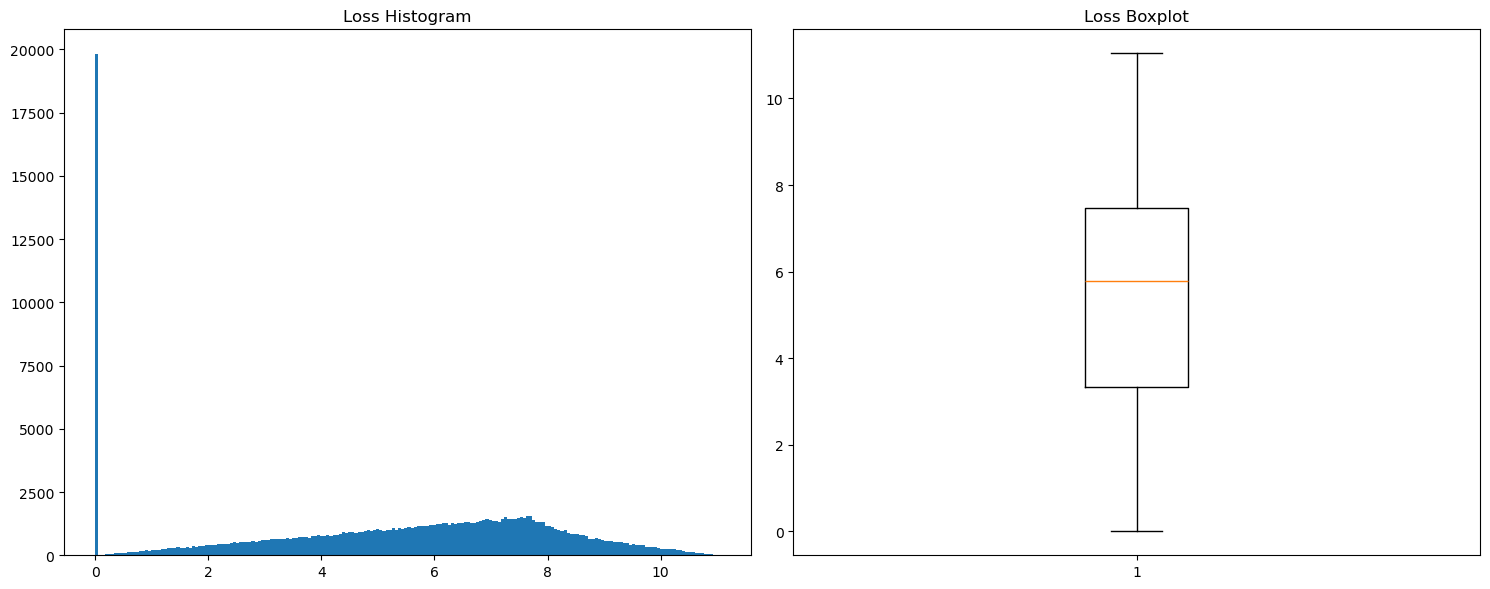

In [13]:
import matplotlib.pyplot as plt

fig,axes=plt.subplots(1,2, figsize=(15, 6))
axes[0].hist(losses1.flatten(), bins=200)
axes[0].set_title('Loss Histogram')
axes[1].boxplot(losses1.flatten(), showfliers=True)
axes[1].set_title('Loss Boxplot')
plt.tight_layout()
plt.show()

In [14]:
# losses1_subpixel= get_gt_loss_subpixel_refinment(loader1,device, org_h, org_w, W_h, H_h)

In [15]:
# np.mean(losses1_subpixel)

In [16]:
# for HRNET 256*192
joints = 14
device = get_device()
in_height2, in_width2= 192,256
H_h2, W_h2= 48,64
sigma2=2

In [17]:
loader2= get_loader(in_height2, in_width2, H_h2, W_h2, sigma2)

In [18]:

losses2= get_gt_loss(loader2,device, org_h, org_w, W_h2, H_h2)

100%|██████████| 355/355 [03:50<00:00,  1.54it/s]


In [19]:
print(f'mean: {np.mean(losses2)}')
print(f'median: {np.median(losses2)}')
print(f'std: {np.std(losses2)}')
print(f'min: {np.min(losses2)}')
print(f'max: {np.max(losses2)}')

mean: 14.181662559509277
median: 15.618942260742188
std: 7.795971393585205
min: 0.0
max: 29.89718246459961


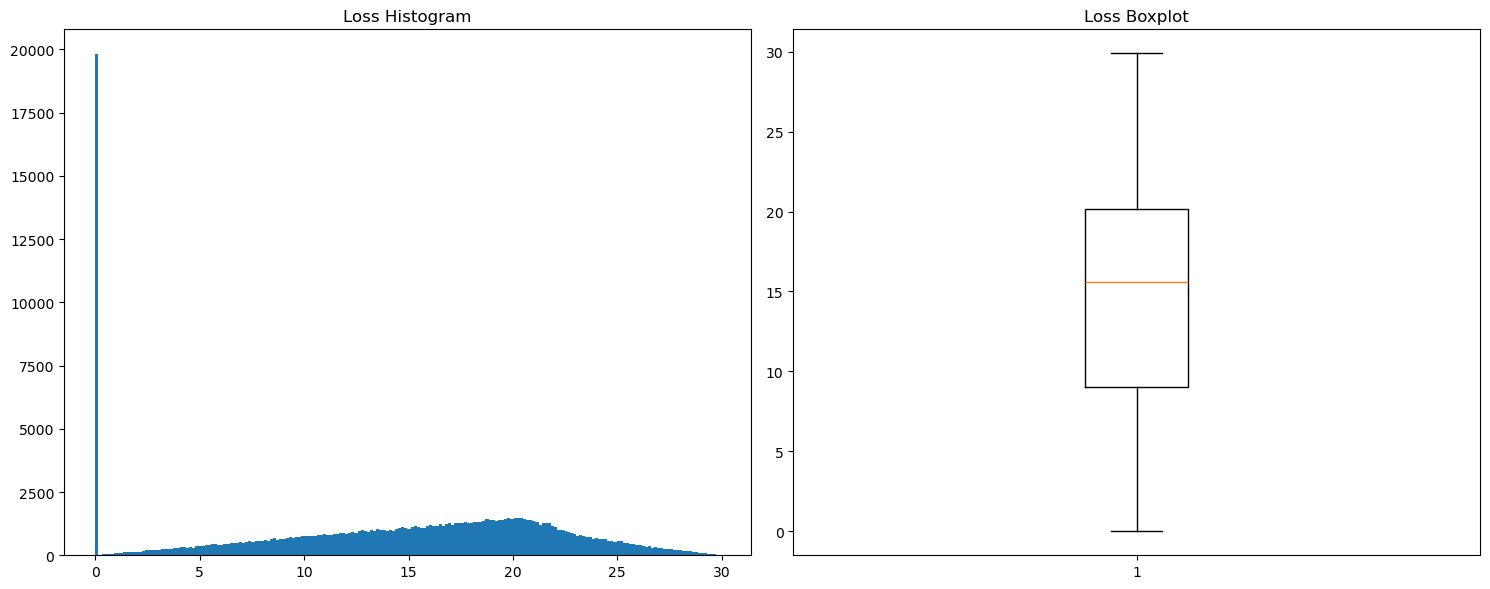

In [20]:
import matplotlib.pyplot as plt

fig,axes=plt.subplots(1,2, figsize=(15, 6))
axes[0].hist(losses2.flatten(), bins=200)
axes[0].set_title('Loss Histogram')
axes[1].boxplot(losses2.flatten(), showfliers=True)
axes[1].set_title('Loss Boxplot')
plt.tight_layout()
plt.show()

In [21]:
# losses2_subpixel= get_gt_loss_subpixel_refinment(loader2,device, org_h, org_w, W_h2, H_h2)

In [22]:
# np.mean(losses2_subpixel)

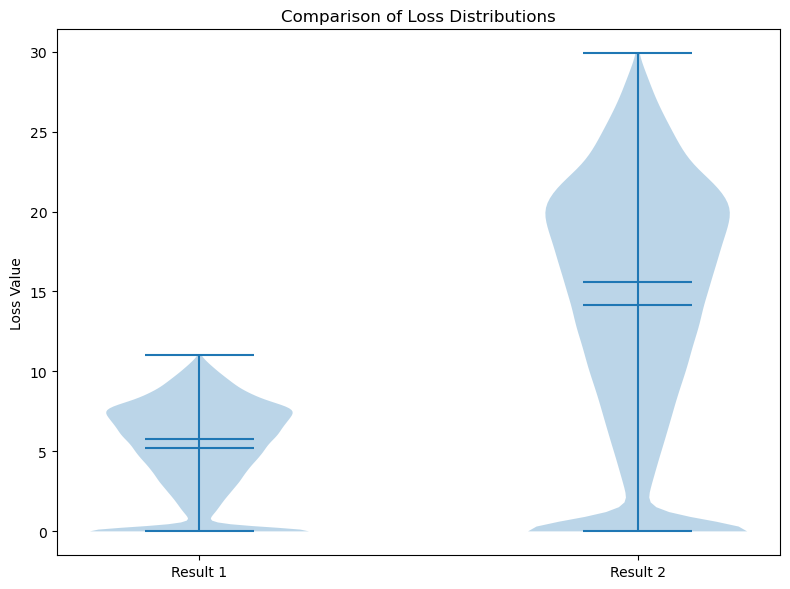

In [23]:
import matplotlib.pyplot as plt

# Assuming you have two sets of losses: losses1 and losses2
data_to_plot = [losses1.flatten(), losses2.flatten()]

fig, ax = plt.subplots(figsize=(8, 6))

violin_parts = ax.violinplot(data_to_plot, showmeans=True, showmedians=True)

# Formatting
ax.set_title('Comparison of Loss Distributions')
ax.set_xticks([1, 2])
ax.set_xticklabels(['Result 1', 'Result 2'])
ax.set_ylabel('Loss Value')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1863881/126758809.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Input resolution', y='Quantization error', data=df, inner="quartile", palette="muted")


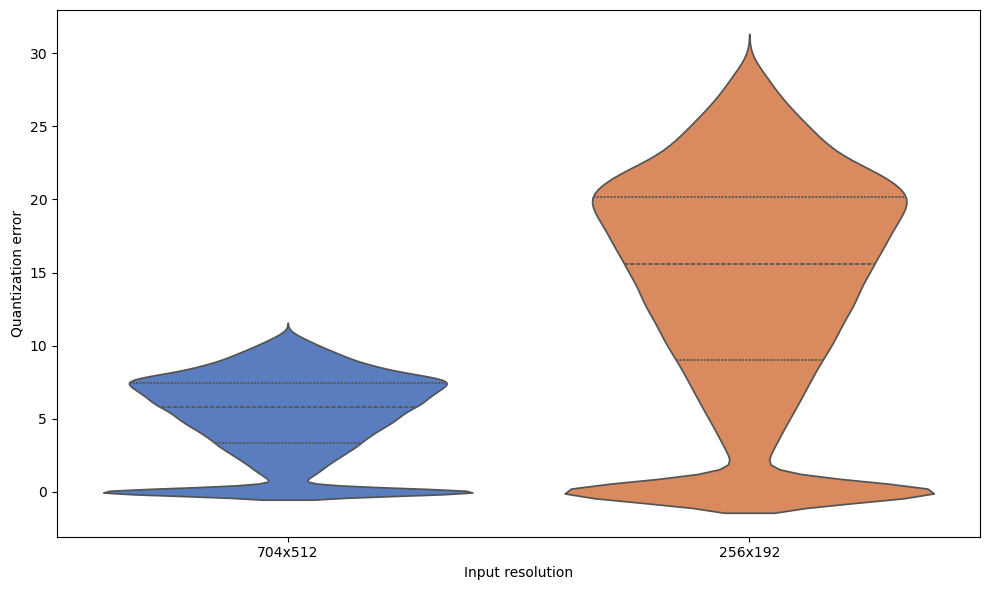

In [31]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the data
# We structure the data as a list of dictionaries, one per loss value
data = []
for val in losses1.flatten():
    data.append({'Input resolution': '704x512', 'Quantization error': val})
for val in losses2.flatten():
    data.append({'Input resolution': '256x192', 'Quantization error': val})

df = pd.DataFrame(data)

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.violinplot(x='Input resolution', y='Quantization error', data=df, inner="quartile", palette="muted")

# 3. Styling
# plt.title('Comparison of Loss Distributions')
# If your losses vary by orders of magnitude, a log scale is often better
# plt.yscale('log') 

plt.tight_layout()
plt.show()

In [25]:
! pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
